## **BITCOIN PRICE FORECASTING**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [2]:
df = pd.read_csv('/content/Bitcoin Historical Data (1).csv')


print(df.head())


         Date     Price      Open      High       Low     Vol. Change %
0  24-03-2024  67,211.9  64,036.5  67,587.8  63,812.9   65.59K    4.96%
1  23-03-2024  64,037.8  63,785.6  65,972.4  63,074.9   35.11K    0.40%
2  22-03-2024  63,785.5  65,501.5  66,633.3  62,328.3   72.43K   -2.62%
3  21-03-2024  65,503.8  67,860.0  68,161.7  64,616.1   75.26K   -3.46%
4  20-03-2024  67,854.0  62,046.8  68,029.5  60,850.9  133.53K    9.35%


In [3]:
print("Shape of data:", df.shape)

Shape of data: (4999, 7)


In [4]:
#checking the type of datatype in the columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      4999 non-null   object
 1   Price     4999 non-null   object
 2   Open      4999 non-null   object
 3   High      4999 non-null   object
 4   Low       4999 non-null   object
 5   Vol.      4993 non-null   object
 6   Change %  4999 non-null   object
dtypes: object(7)
memory usage: 273.5+ KB


In [5]:
#checking if their is any null values
df.isnull().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,6
Change %,0


In [6]:
# Converting Date column to proper date format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [7]:
# Remove commas from price columns and convert to numbers
for col in ['Price', 'Open', 'High', 'Low']:
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

In [8]:
df['Vol.'] = df['Vol.'].fillna(0)#filling null values with zero

In [9]:
def convert_volume(x):
    if pd.isna(x):
        return None
    x = str(x).strip()

    if 'K' in x:
        return float(x.replace('K', '')) * 1_000
    elif 'M' in x:
        return float(x.replace('M', '')) * 1_000_000
    elif 'B' in x:
        return float(x.replace('B', '')) * 1_000_000_000
    else:
        return float(x)



In [10]:
df['Vol.'] = df['Vol.'].apply(convert_volume)

In [11]:
# Fixing Change% column
df['Change %'] = df['Change %'].astype(str).str.rstrip('%').astype(float) / 100

In [12]:
# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

In [13]:
# changing name Price to Close Price
df.rename(columns={'Price': 'Close Price'}, inplace=True)

In [14]:
df

,Date,Close Price,Open,High,Low,Vol.,Change %
0,2010-07-18,0.1,0.0,0.1,0.1,80.0,0.0000
1,2010-07-19,0.1,0.1,0.1,0.1,570.0,0.0000
2,2010-07-20,0.1,0.1,0.1,0.1,260.0,0.0000
3,2010-07-21,0.1,0.1,0.1,0.1,580.0,0.0000
4,2010-07-22,0.1,0.1,0.1,0.1,2160.0,0.0000
...,...,...,...,...,...,...,...
4994,2024-03-20,67854.0,62046.8,68029.5,60850.9,133530.0,0.0935
4995,2024-03-21,65503.8,67860.0,68161.7,64616.1,75260.0,-0.0346
4996,2024-03-22,63785.5,65501.5,66633.3,62328.3,72430.0,-0.0262
4997,2024-03-23,64037.8,63785.6,65972.4,63074.9,35110.0,0.0040


In [15]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, SimpleRNN, Dense, Dropout,
    Conv1D, GlobalAveragePooling1D,
    Input, MultiHeadAttention, LayerNormalization, Add
)
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
tf.random.set_seed(42)

In [16]:
# Take only the Close Price column
dataset = df['Close Price'].values.reshape(-1, 1)
print("Dataset shape:", dataset.shape)

Dataset shape: (4999, 1)


In [17]:
# Spliting into Train and Test FIRST (no shuffle  as it is time based forcaste)
TRAIN_SIZE      = 4000
SEQUENCE_LENGTH = 60   # useing last 60 days to predict future

In [18]:
train_raw = dataset[:TRAIN_SIZE]
test_raw  = dataset[TRAIN_SIZE:]

In [19]:
# Scaleing the data between 0 and 1
min_max    = MinMaxScaler()
min_max.fit(train_raw)

train_scaled = min_max.transform(train_raw)

In [20]:
# For test sequences we need last 60 days of train as context
test_with_context = np.concatenate([train_scaled[-SEQUENCE_LENGTH:],
                                     min_max.transform(test_raw)], axis=0)

In [21]:
scaled_dataset = min_max.transform(dataset)

print("Train size:", len(train_scaled))
print("Test size:", len(test_raw))

Train size: 4000
Test size: 999


In [22]:
# CREATEING SEQUENCES (SLIDING WINDOW)

In [23]:
def create_sequences(data, sequence_length, forecast_days):
    X = []
    y = []


    total_needed = sequence_length + forecast_days

    for i in range(len(data) - total_needed + 1):
        # Input: 60 days of prices
        X.append(data[i : i + sequence_length, 0])
        # Output: next forecast_days prices
        y.append(data[i + sequence_length : i + sequence_length + forecast_days, 0])

    X = np.array(X)
    y = np.array(y)

    # Reshape X for deep learning: (samples, time_steps, features)
    X = X.reshape(-1, sequence_length, 1)

    # If only 1 day forecast, flatten y to 1D
    if forecast_days == 1:
        y = y.ravel()

    return X, y









In [24]:
# Createing training sequences for 1-day, 3-day, 7-day
x_train_1d, y_train_1d = create_sequences(train_scaled, SEQUENCE_LENGTH, 1)
x_train_3d, y_train_3d = create_sequences(train_scaled, SEQUENCE_LENGTH, 3)
x_train_7d, y_train_7d = create_sequences(train_scaled, SEQUENCE_LENGTH, 7)

In [25]:
# Createing test sequences for 1-day, 3-day, 7-day
x_test_1d, y_test_1d = create_sequences(test_with_context, SEQUENCE_LENGTH, 1)
x_test_3d, y_test_3d = create_sequences(test_with_context, SEQUENCE_LENGTH, 3)
x_test_7d, y_test_7d = create_sequences(test_with_context, SEQUENCE_LENGTH, 7)

In [26]:
print("Train 1-Day shapes:", x_train_1d.shape, y_train_1d.shape)
print("Train 3-Day shapes:", x_train_3d.shape, y_train_3d.shape)
print("Train 7-Day shapes:", x_train_7d.shape, y_train_7d.shape)
print("Test  1-Day shapes:", x_test_1d.shape,  y_test_1d.shape)

Train 1-Day shapes: (3940, 60, 1) (3940,)
Train 3-Day shapes: (3938, 60, 1) (3938, 3)
Train 7-Day shapes: (3934, 60, 1) (3934, 7)
Test  1-Day shapes: (999, 60, 1) (999,)


In [27]:




def get_real_scale_predictions(model, x_test_1d, y_test_1d,
                                       x_test_3d, y_test_3d,
                                       x_test_7d, y_test_7d):

    # ✅ Helper: always reshape to (-1, 1) before inverse_transform, then reshape back
    def inv(arr):
        original_shape = arr.shape
        return min_max.inverse_transform(
            arr.reshape(-1, 1)
        ).reshape(original_shape)

    # 1-Day
    pred_1d   = inv(model[0].predict(x_test_1d))          # shape (N, 1)
    actual_1d = inv(y_test_1d.reshape(-1, 1))              # shape (N, 1)

    # 3-Day  ← THIS was broken before
    pred_3d   = inv(model[1].predict(x_test_3d))           # shape (N, 3)
    actual_3d = inv(y_test_3d)                             # shape (N, 3)

    # 7-Day  ← THIS was broken before
    pred_7d   = inv(model[2].predict(x_test_7d))           # shape (N, 7)
    actual_7d = inv(y_test_7d)                             # shape (N, 7)

    return pred_1d, actual_1d, pred_3d, actual_3d, pred_7d, actual_7d



























In [28]:
#To calculate the accuracy of model

def print_metrics(model_name, pred_1d, actual_1d,
                               pred_3d, actual_3d,
                               pred_7d, actual_7d):
    """
    Print MAE, RMSE, MAPE for all 3 horizons.
    """
    print(f"\n= {model_name} — Real Scale Metrics ==")

    # 1-Day metrics
    mae_1d  = mean_absolute_error(actual_1d, pred_1d)
    rmse_1d = np.sqrt(mean_squared_error(actual_1d, pred_1d))
    mape_1d = np.mean(np.abs((actual_1d - pred_1d) / actual_1d)) * 100
    print(f"1-Day → MAE: ${mae_1d:.2f}  | RMSE: ${rmse_1d:.2f}  | MAPE: {mape_1d:.2f}%")

    # 3-Day metrics (using Day-1 column)
    mae_3d  = mean_absolute_error(actual_3d[:, 0], pred_3d[:, 0])
    rmse_3d = np.sqrt(mean_squared_error(actual_3d[:, 0], pred_3d[:, 0]))
    mape_3d = np.mean(np.abs((actual_3d[:, 0] - pred_3d[:, 0]) / actual_3d[:, 0])) * 100
    print(f"3-Day → MAE: ${mae_3d:.2f}  | RMSE: ${rmse_3d:.2f}  | MAPE: {mape_3d:.2f}%")

    # 7-Day metrics (using Day-1 column)
    mae_7d  = mean_absolute_error(actual_7d[:, 0], pred_7d[:, 0])
    rmse_7d = np.sqrt(mean_squared_error(actual_7d[:, 0], pred_7d[:, 0]))
    mape_7d = np.mean(np.abs((actual_7d[:, 0] - pred_7d[:, 0]) / actual_7d[:, 0])) * 100
    print(f"7-Day → MAE: ${mae_7d:.2f}  | RMSE: ${rmse_7d:.2f}  | MAPE: {mape_7d:.2f}%")

    return mae_1d, mae_3d, mae_7d

In [29]:
def plot_loss(history, model_name, horizon):
    """
    Plot training vs validation loss curve.
    """
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'],     label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f"{model_name} {horizon} — Loss Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [30]:



def plot_predictions(model_name, pred_1d, actual_1d,
                                  pred_3d, actual_3d,
                                  pred_7d, actual_7d):

    # 1-Day plot — unchanged
    plt.figure(figsize=(12, 5))
    plt.plot(actual_1d, label="Actual Price",    color='steelblue')
    plt.plot(pred_1d,   label="Predicted Price", color='tomato', linestyle='--')
    plt.title(f"{model_name} — 1-Day Forecast: Actual vs Predicted")
    plt.xlabel("Time (test samples)")
    plt.ylabel("Price (USD)")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    # 3-Day plot — show Day 1 AND Day 3 side by side

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, col_idx, label in zip(axes, [0, 2], ["Day 1", "Day 3"]):
        ax.plot(actual_3d[:, col_idx], label="Actual",    color='steelblue')
        ax.plot(pred_3d[:, col_idx],   label="Predicted", color='tomato', linestyle='--')
        ax.set_title(f"{model_name} — 3-Day Forecast ({label})")
        ax.set_xlabel("Time (test samples)")
        ax.set_ylabel("Price (USD)")
        ax.legend(); ax.grid(True)
    plt.tight_layout(); plt.show()

    # 7-Day plot — show Day 1 AND Day 7 side by side

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, col_idx, label in zip(axes, [0, 6], ["Day 1", "Day 7"]):
        ax.plot(actual_7d[:, col_idx], label="Actual",    color='steelblue')
        ax.plot(pred_7d[:, col_idx],   label="Predicted", color='tomato', linestyle='--')
        ax.set_title(f"{model_name} — 7-Day Forecast ({label})")  # ✅ title now correct
        ax.set_xlabel("Time (test samples)")
        ax.set_ylabel("Price (USD)")
        ax.legend(); ax.grid(True)
    plt.tight_layout(); plt.show()

In [31]:
def plot_error_distribution(model_name, pred_1d, actual_1d,
                                         pred_3d, actual_3d,
                                         pred_7d, actual_7d):
    """
    Plot error distribution histograms for all 3 horizons.
    """
    errors_1d = actual_1d.flatten() - pred_1d.flatten()
    errors_3d = actual_3d[:, 0]     - pred_3d[:, 0]
    errors_7d = actual_7d[:, 0]     - pred_7d[:, 0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, errors, label, color in zip(
        axes,
        [errors_1d, errors_3d, errors_7d],
        ["1-Day", "3-Day", "7-Day"],
        ["steelblue", "darkorange", "green"]
    ):
        ax.hist(errors, bins=40, color=color, alpha=0.75, edgecolor='white')
        ax.axvline(0, color='black', linewidth=1, linestyle='--')
        ax.set_title(f"{model_name} {label} — Error Distribution")
        ax.set_xlabel("Prediction Error (USD)")
        ax.set_ylabel("Frequency")
        ax.grid(True, alpha=0.3)

    plt.suptitle(f"{model_name} — Error Distribution", fontsize=13)
    plt.tight_layout()
    plt.show()

In [32]:
def plot_horizon_mae(model_name, mae_1d, mae_3d, mae_7d):
    """
    Bar chart comparing MAE across 3 forecast horizons.
    """
    plt.figure(figsize=(7, 4))
    horizons = ['1-Day', '3-Day', '7-Day']
    maes     = [mae_1d, mae_3d, mae_7d]
    colors   = ['steelblue', 'darkorange', 'green']
    bars = plt.bar(horizons, maes, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, maes):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 20,
                 f'${val:.0f}', ha='center', fontsize=11)
    plt.title(f"{model_name} — Forecast Horizon MAE Comparison")
    plt.ylabel("Mean Absolute Error (USD)")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [33]:



def print_future_forecast(model_name, model_1d, model_3d, model_7d):
    last_60 = test_with_context[-60:].reshape(1, 60, 1)  # ✅ safer and consistent

def inv(arr):
    return min_max.inverse_transform(arr.reshape(-1, 1))

    p1 = inv(model_1d.predict(last_60))
    p3 = inv(model_3d.predict(last_60))
    p7 = inv(model_7d.predict(last_60))

    print(f"\n[{model_name}] Future Price Forecast:")
    print(f"  Next 1 day:   ${p1[0][0]:.2f}")
    print(f"  Next 3 days:  {[round(float(v), 2) for v in p3.flatten()[:3]]}")
    print(f"  Next 7 days:  {[round(float(v), 2) for v in p7.flatten()[:7]]}")

# **LSTM**

In [34]:
def build_lstm(output_days):
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=(60, 1)))
    model.add(LSTM(50,  return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(output_days))
    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name='mae'),
            tf.keras.metrics.MeanAbsolutePercentageError(name='mape'),
            tf.keras.metrics.RootMeanSquaredError(name='rmse')
        ]
    )
    return model

In [35]:

# preparing 3 LSTM models one for each forecast horizon
lstm_model_1d = build_lstm(1)
lstm_model_3d = build_lstm(3)
lstm_model_7d = build_lstm(7)

lstm_model_1d.summary()
lstm_model_3d.summary()
lstm_model_7d.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,301 (282.43 KB)

 Trainable params: 72,301 (282.43 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           182 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,457 (283.04 KB)

 Trainable params: 72,457 (283.04 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Training all 3 LSTM models
print("\nTraining LSTM 1-Day model...")
Lstm_hist_1d = lstm_model_1d.fit(x_train_1d, y_train_1d,
                                   epochs=50, batch_size=16,
                                   validation_split=0.1, verbose=1)


Training LSTM 1-Day model...
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 1.4631e-04 - mae: 0.0065 - mape: 68506.7344 - rmse: 0.0121 - val_loss: 0.0019 - val_mae: 0.0284 - val_mape: 5.7128 - val_rmse: 0.0438
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 6.0232e-05 - mae: 0.0048 - mape: 37418.8633 - rmse: 0.0078 - val_loss: 0.0018 - val_mae: 0.0287 - val_mape: 5.2922 - val_rmse: 0.0429
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.0331e-05 - mae: 0.0044 - mape: 32653.1055 - rmse: 0.0071 - val_loss: 0.0019 - val_mae: 0.0291 - val_mape: 5.4675 - val_rmse: 0.0440
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 4.3269e-05 - mae: 0.0041 - mape: 31355.7363 - rmse: 0.0066 - val_loss: 0.0020 - val_mae: 0.0295 - val_mape: 5.5310 - val_rmse: 0.0447
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 3.8365e-05 - mae: 0.0038 - mape: 30664.1406 - rmse: 0.0062 - val_loss: 0.0020 - val_mae: 0.0302 - val_mape: 5.6136 - val_rmse: 0.

In [37]:
print("\nTraining LSTM 3-Day model...")
Lstm_hist_3d = lstm_model_3d.fit(x_train_3d, y_train_3d,
                                   epochs=50, batch_size=16,
                                   validation_split=0.1, verbose=1)


Training LSTM 3-Day model...
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 1.5589e-04 - mae: 0.0067 - mape: 60692.4102 - rmse: 0.0125 - val_loss: 0.0047 - val_mae: 0.0443 - val_mape: 8.4359 - val_rmse: 0.0689
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 7.4126e-05 - mae: 0.0051 - mape: 45149.4414 - rmse: 0.0086 - val_loss: 0.0068 - val_mae: 0.0516 - val_mape: 8.3922 - val_rmse: 0.0827
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5.9632e-05 - mae: 0.0045 - mape: 38298.6836 - rmse: 0.0077 - val_loss: 0.0080 - val_mae: 0.0573 - val_mape: 9.1326 - val_rmse: 0.0894
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.1581e-05 - mae: 0.0041 - mape: 33372.3008 - rmse: 0.0072 - val_loss: 0.0085 - val_mae: 0.0602 - val_mape: 9.6731 - val_rmse: 0.0922
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.6572e-05 - mae: 0.0039 - mape: 29405.2422 - rmse: 0.0068 - val_loss: 0.0085 - val_mae: 0.0607 - val_mape: 9.9074 - val_rmse: 0.

In [38]:
print("\nTraining LSTM 7-Day model...")
Lstm_hist_7d = lstm_model_7d.fit(x_train_7d, y_train_7d,
                                   epochs=50, batch_size=16,
                                   validation_split=0.1, verbose=1)


Training LSTM 7-Day model...
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 2.5072e-04 - mae: 0.0084 - mape: 61367.1250 - rmse: 0.0158 - val_loss: 0.0205 - val_mae: 0.0935 - val_mape: 14.8546 - val_rmse: 0.1432
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 1.0376e-04 - mae: 0.0058 - mape: 35373.3320 - rmse: 0.0102 - val_loss: 0.0219 - val_mae: 0.0975 - val_mape: 15.4236 - val_rmse: 0.1481
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 9.2348e-05 - mae: 0.0055 - mape: 34571.2109 - rmse: 0.0096 - val_loss: 0.0215 - val_mae: 0.0970 - val_mape: 15.4495 - val_rmse: 0.1465
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.4422e-05 - mae: 0.0052 - mape: 33107.3789 - rmse: 0.0092 - val_loss: 0.0214 - val_mae: 0.0980 - val_mape: 15.8353 - val_rmse: 0.1464
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 7.9009e-05 - mae: 0.0051 - mape: 31995.1543 - rmse: 0.0089 - val_loss: 0.0218 - val_mae: 0.1001 - val_mape: 16.4832 - val_rms

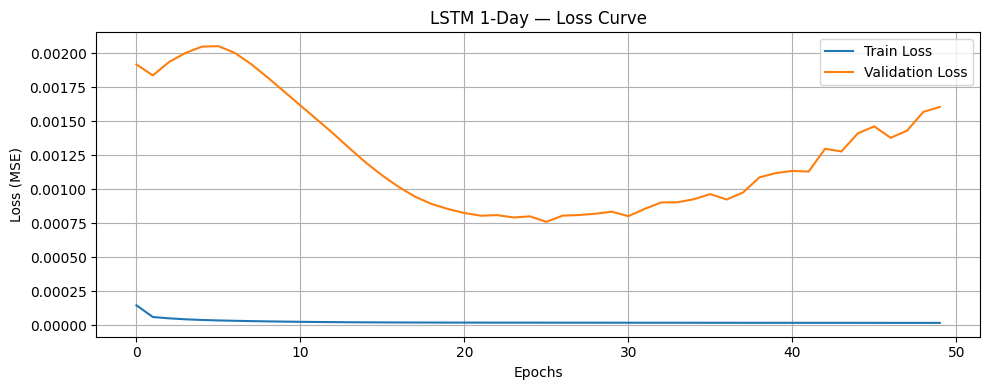

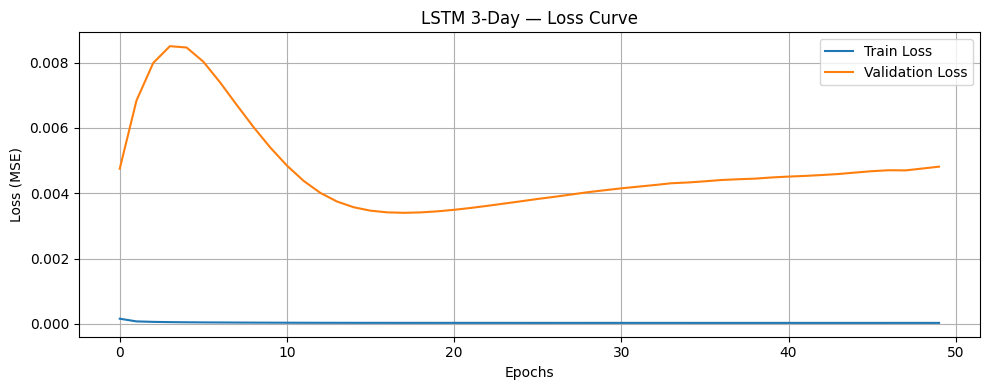

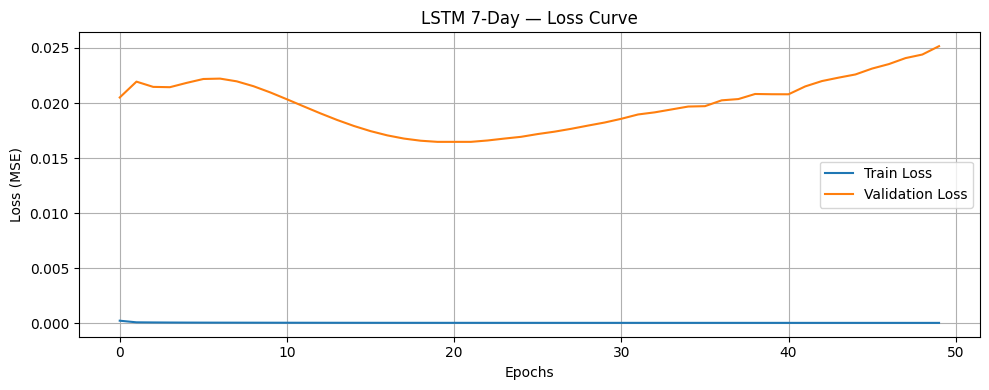

In [39]:
# Ploting loss curves for all 3 LSTM models
plot_loss(Lstm_hist_1d, "LSTM", "1-Day")
plot_loss(Lstm_hist_3d, "LSTM", "3-Day")
plot_loss(Lstm_hist_7d, "LSTM", "7-Day")

In [40]:
#  predictions
lstm_pred_1d, lstm_actual_1d, \
lstm_pred_3d, lstm_actual_3d, \
lstm_pred_7d, lstm_actual_7d = get_real_scale_predictions(
    [lstm_model_1d, lstm_model_3d, lstm_model_7d],
    x_test_1d, y_test_1d,
    x_test_3d, y_test_3d,
    x_test_7d, y_test_7d
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [41]:
#  metrics
lstm_mae_1d, lstm_mae_3d, lstm_mae_7d = print_metrics(
    "LSTM",
    lstm_pred_1d, lstm_actual_1d,
    lstm_pred_3d, lstm_actual_3d,
    lstm_pred_7d, lstm_actual_7d
)


= LSTM — Real Scale Metrics ==
1-Day → MAE: $1733.49  | RMSE: $2440.59  | MAPE: 4.39%
3-Day → MAE: $2281.79  | RMSE: $3264.74  | MAPE: 5.51%
7-Day → MAE: $5752.90  | RMSE: $7501.12  | MAPE: 14.42%


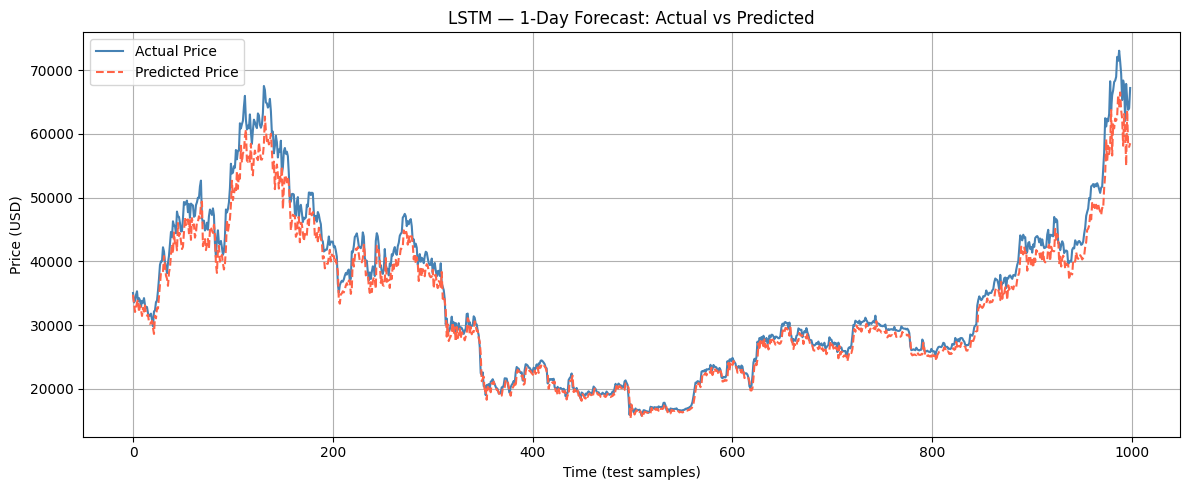

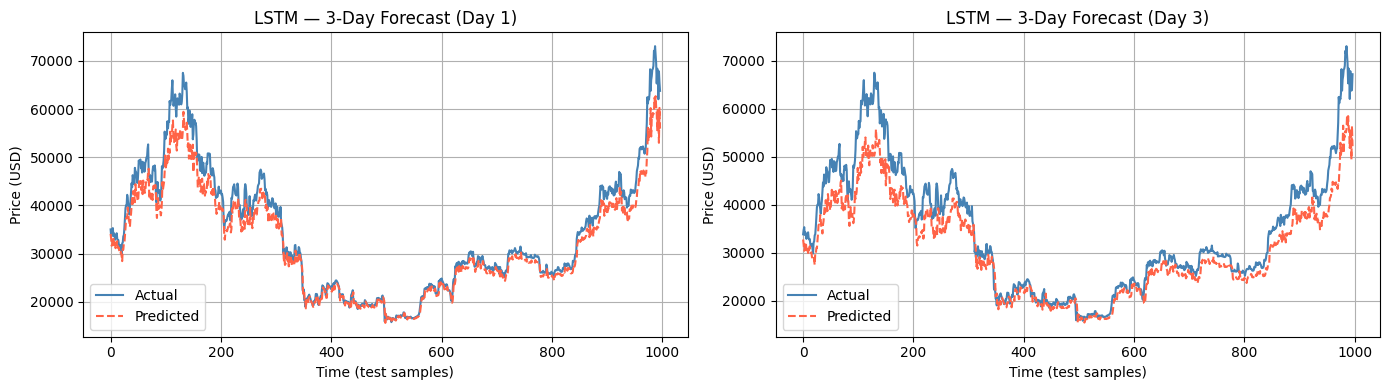

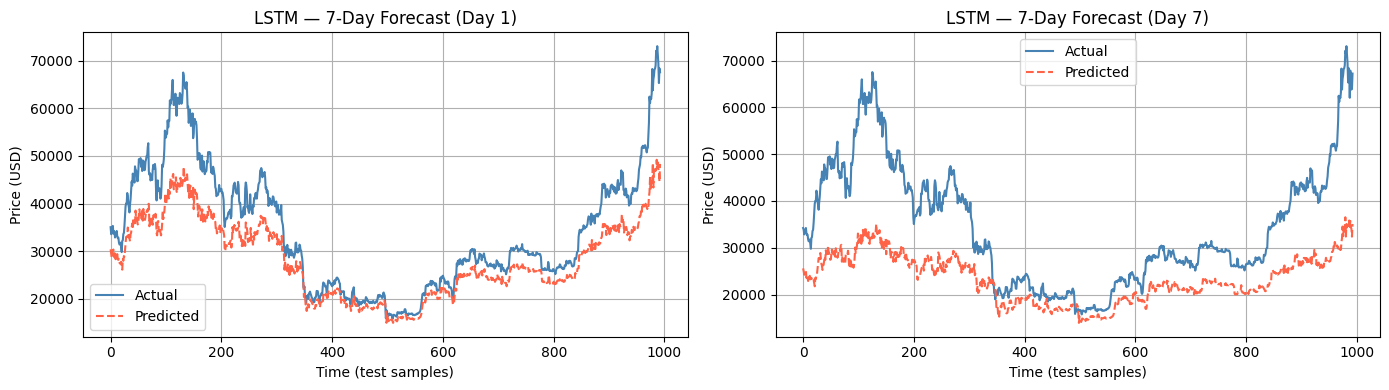

In [42]:
# Ploting predictions
plot_predictions("LSTM",
                 lstm_pred_1d, lstm_actual_1d,
                 lstm_pred_3d, lstm_actual_3d,
                 lstm_pred_7d, lstm_actual_7d)

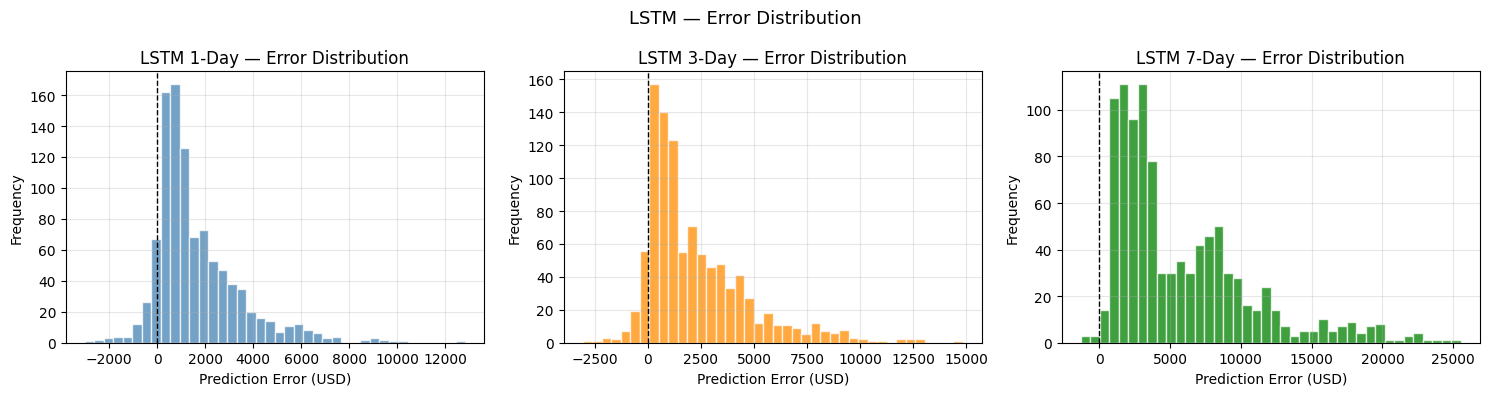

In [43]:
# Ploting error distributions
plot_error_distribution("LSTM",
                         lstm_pred_1d, lstm_actual_1d,
                         lstm_pred_3d, lstm_actual_3d,
                         lstm_pred_7d, lstm_actual_7d)

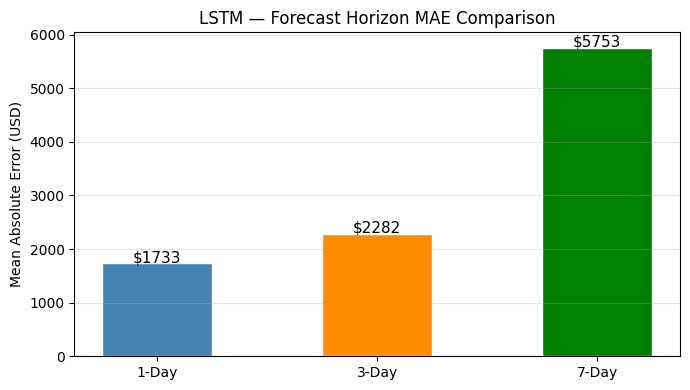

In [44]:
plot_horizon_mae("LSTM", lstm_mae_1d, lstm_mae_3d, lstm_mae_7d)

In [45]:
# Future forecast
print_future_forecast("LSTM", lstm_model_1d, lstm_model_3d, lstm_model_7d)

# **RNN**

In [46]:
def build_rnn(output_days):
    model = Sequential()
    model.add(SimpleRNN(100, return_sequences=True, input_shape=(60, 1)))
    model.add(SimpleRNN(50,  return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(output_days))
    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name='mae'),
            tf.keras.metrics.MeanAbsolutePercentageError(name='mape'),
            tf.keras.metrics.RootMeanSquaredError(name='rmse')
        ]
    )
    return model

In [47]:
#  RNN models
rnn_model_1d = build_rnn(1)
rnn_model_3d = build_rnn(3)
rnn_model_7d = build_rnn(7)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:

rnn_model_1d.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 100)        │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         7,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,051 (74.42 KB)

 Trainable params: 19,051 (74.42 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Training all 3 RNN models
print("\nTraining RNN 1-Day model...")
Rnn_hist_1d = rnn_model_1d.fit(x_train_1d, y_train_1d,
                                 epochs=50, batch_size=16,
                                 validation_split=0.1, verbose=1)


Training RNN 1-Day model...
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0023 - mae: 0.0176 - mape: 158422.9375 - rmse: 0.0484 - val_loss: 0.0295 - val_mae: 0.1115 - val_mape: 17.0053 - val_rmse: 0.1717
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.6459e-05 - mae: 0.0067 - mape: 56974.5039 - rmse: 0.0098 - val_loss: 0.0162 - val_mae: 0.0827 - val_mape: 13.4025 - val_rmse: 0.1271
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 6.2227e-05 - mae: 0.0052 - mape: 44037.3789 - rmse: 0.0079 - val_loss: 0.0113 - val_mae: 0.0692 - val_mape: 11.5962 - val_rmse: 0.1064
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 4.8774e-05 - mae: 0.0047 - mape: 39207.6914 - rmse: 0.0070 - val_loss: 0.0092 - val_mae: 0.0620 - val_mape: 10.1228 - val_rmse: 0.0961
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.3691e-05 - mae: 0.0044 - mape: 35034.0703 - rmse: 0.0066 - val_loss: 0.0072 - val_mae: 0.0550 - val_mape: 9.1687 - val_rmse: 0.

In [50]:
print("\nTraining RNN 3-Day model...")
Rnn_hist_3d = rnn_model_3d.fit(x_train_3d, y_train_3d,
                                 epochs=50, batch_size=16,
                                 validation_split=0.1, verbose=1)


Training RNN 3-Day model...
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0012 - mae: 0.0134 - mape: 160398.7656 - rmse: 0.0343 - val_loss: 0.0434 - val_mae: 0.1374 - val_mape: 21.1006 - val_rmse: 0.2083
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.0319e-04 - mae: 0.0061 - mape: 50707.5820 - rmse: 0.0102 - val_loss: 0.0322 - val_mae: 0.1188 - val_mape: 18.2387 - val_rmse: 0.1794
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 8.0907e-05 - mae: 0.0053 - mape: 36046.7227 - rmse: 0.0090 - val_loss: 0.0284 - val_mae: 0.1113 - val_mape: 16.8766 - val_rmse: 0.1686
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6.5462e-05 - mae: 0.0047 - mape: 31077.0723 - rmse: 0.0081 - val_loss: 0.0249 - val_mae: 0.1037 - val_mape: 15.6877 - val_rmse: 0.1577
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.7114e-05 - mae: 0.0043 - mape: 28315.0898 - rmse: 0.0076 - val_loss: 0.0211 - val_mae: 0.0954 - val_mape: 14.6395 - val_rmse: 0

In [51]:
print("\nTraining RNN 7-Day model...")
Rnn_hist_7d = rnn_model_7d.fit(x_train_7d, y_train_7d,
                                 epochs=50, batch_size=16,
                                 validation_split=0.1, verbose=1)


Training RNN 7-Day model...
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0026 - mae: 0.0178 - mape: 95023.8125 - rmse: 0.0505 - val_loss: 0.0736 - val_mae: 0.1815 - val_mape: 29.4545 - val_rmse: 0.2712
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.5513e-04 - mae: 0.0070 - mape: 36862.9102 - rmse: 0.0125 - val_loss: 0.0550 - val_mae: 0.1586 - val_mape: 26.2827 - val_rmse: 0.2345
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.1518e-04 - mae: 0.0058 - mape: 27442.4453 - rmse: 0.0107 - val_loss: 0.0454 - val_mae: 0.1419 - val_mape: 23.0416 - val_rmse: 0.2131
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.7804e-05 - mae: 0.0053 - mape: 24724.6641 - rmse: 0.0099 - val_loss: 0.0394 - val_mae: 0.1311 - val_mape: 21.1318 - val_rmse: 0.1985
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 8.7921e-05 - mae: 0.0050 - mape: 23619.6602 - rmse: 0.0094 - val_loss: 0.0350 - val_mae: 0.1231 - val_mape: 19.7438 - val_rmse: 0.

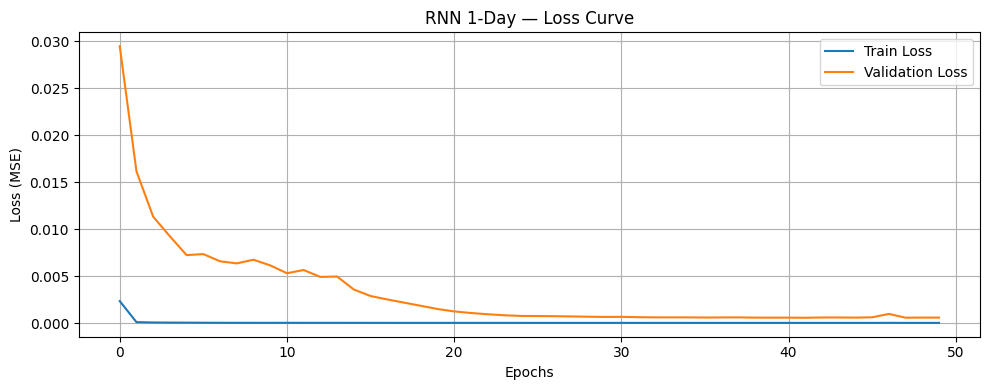

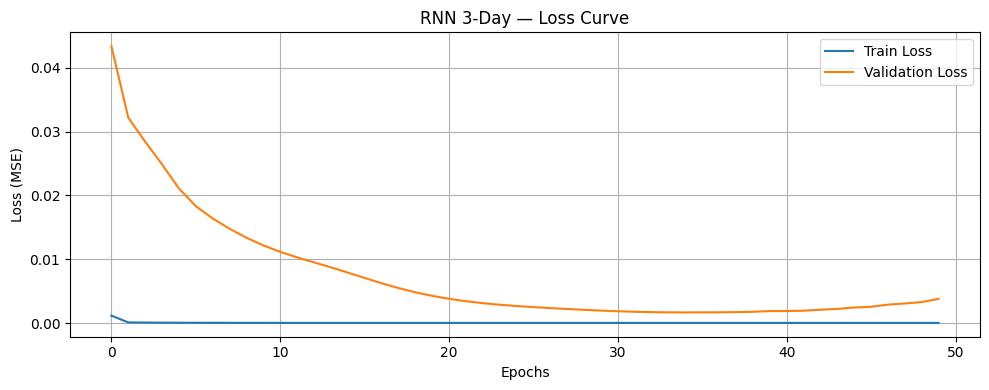

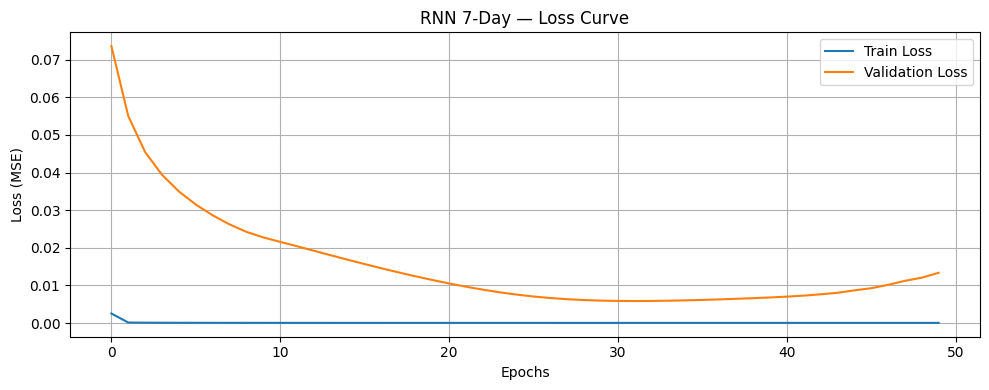

In [52]:
# Ploting loss curves
plot_loss(Rnn_hist_1d, "RNN", "1-Day")
plot_loss(Rnn_hist_3d, "RNN", "3-Day")
plot_loss(Rnn_hist_7d, "RNN", "7-Day")

In [53]:

#  predictions
rnn_pred_1d, rnn_actual_1d, \
rnn_pred_3d, rnn_actual_3d, \
rnn_pred_7d, rnn_actual_7d = get_real_scale_predictions(
    [rnn_model_1d, rnn_model_3d, rnn_model_7d],
    x_test_1d, y_test_1d,
    x_test_3d, y_test_3d,
    x_test_7d, y_test_7d
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


In [54]:
#  metrics
rnn_mae_1d, rnn_mae_3d, rnn_mae_7d = print_metrics(
    "RNN",
    rnn_pred_1d, rnn_actual_1d,
    rnn_pred_3d, rnn_actual_3d,
    rnn_pred_7d, rnn_actual_7d
)



= RNN — Real Scale Metrics ==
1-Day → MAE: $962.11  | RMSE: $1325.65  | MAPE: 2.85%
3-Day → MAE: $2527.51  | RMSE: $3667.17  | MAPE: 6.11%
7-Day → MAE: $6080.89  | RMSE: $7903.44  | MAPE: 15.31%


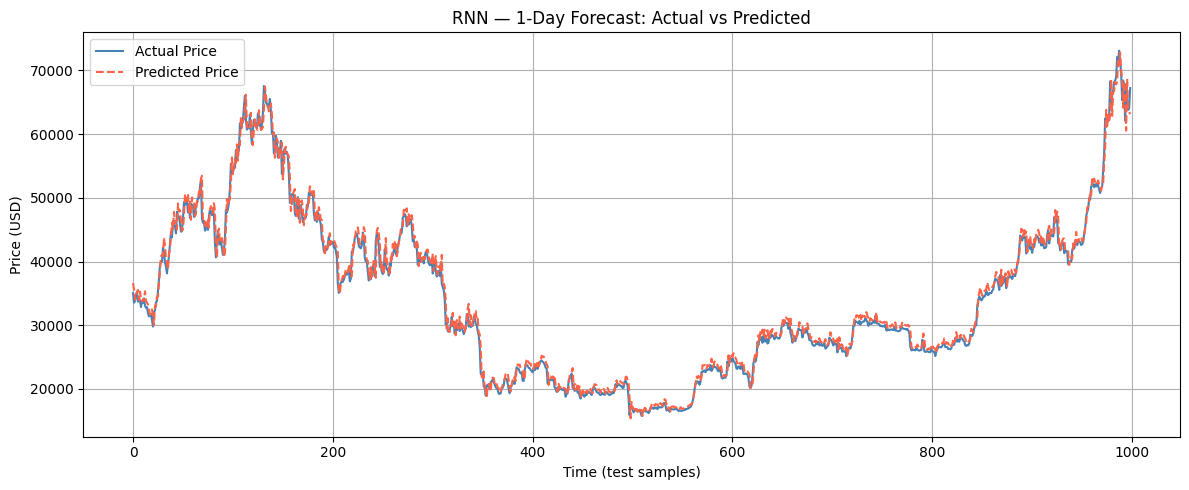

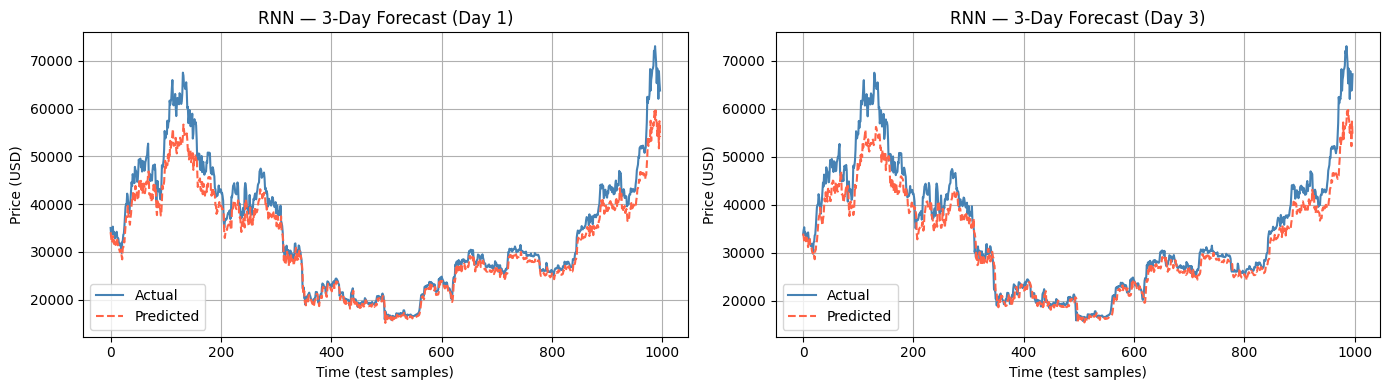

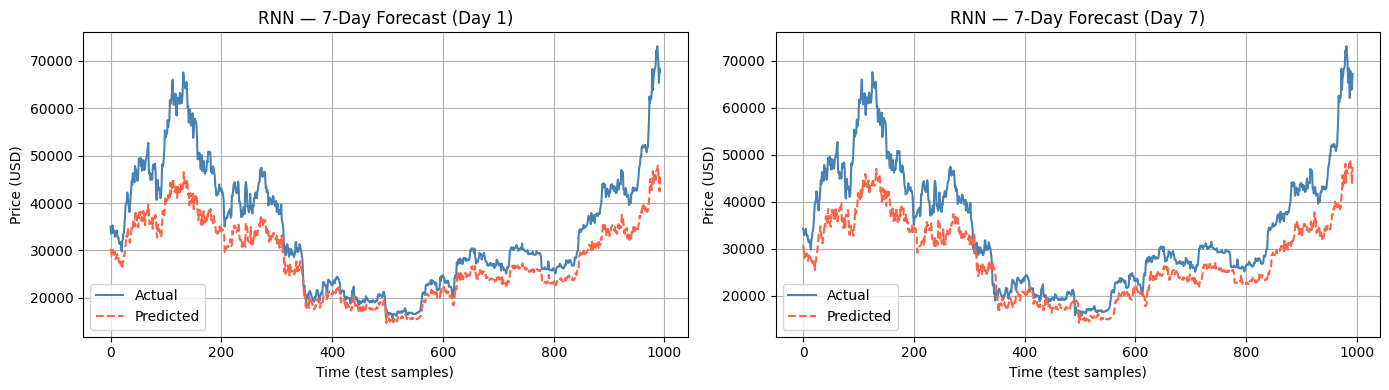

In [55]:
# Ploting predictions
plot_predictions("RNN",
                 rnn_pred_1d, rnn_actual_1d,
                 rnn_pred_3d, rnn_actual_3d,
                 rnn_pred_7d, rnn_actual_7d)

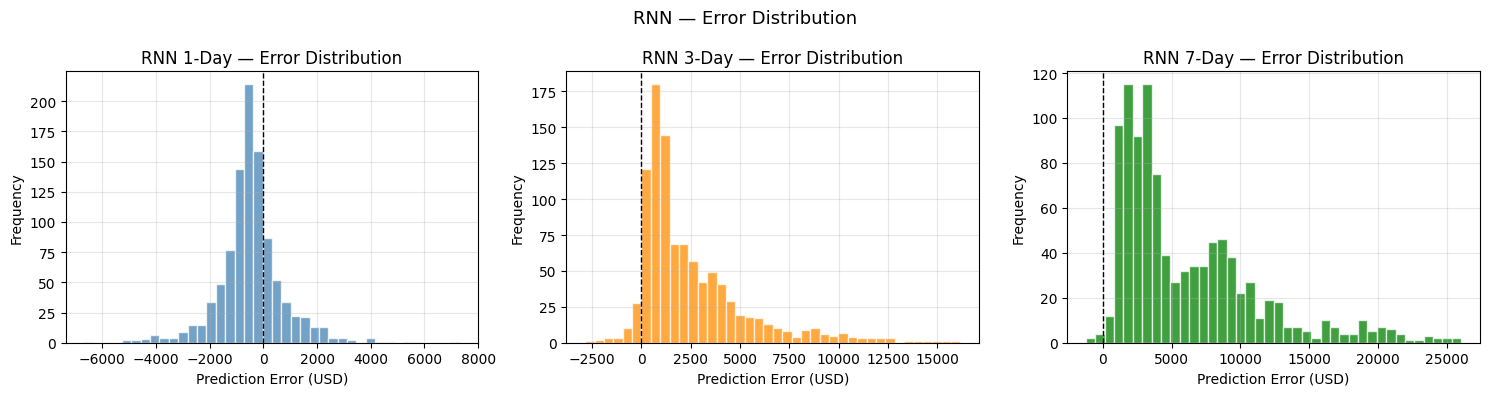

In [56]:
# Ploting error distributions
plot_error_distribution("RNN",
                         rnn_pred_1d, rnn_actual_1d,
                         rnn_pred_3d, rnn_actual_3d,
                         rnn_pred_7d, rnn_actual_7d)

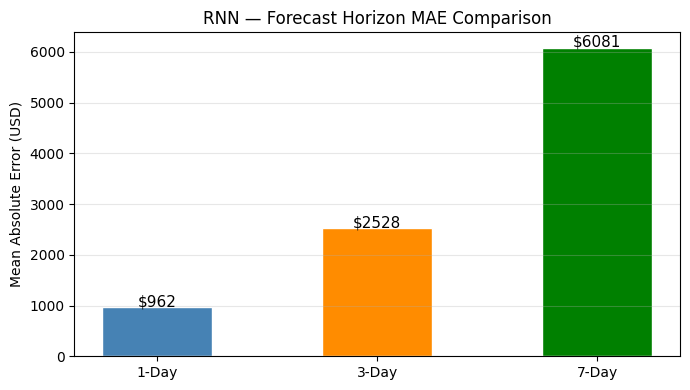

In [57]:
plot_horizon_mae("RNN", rnn_mae_1d, rnn_mae_3d, rnn_mae_7d)

In [58]:
# Future forecast
print_future_forecast("RNN", rnn_model_1d, rnn_model_3d, rnn_model_7d)

# **CNN**

In [59]:

def build_cnn(output_days):
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                     padding='same', input_shape=(60, 1)))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu',
                     padding='same'))
    model.add(GlobalAveragePooling1D())
    model.add(Dense(25))
    model.add(Dense(output_days))
    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name='mae'),
            tf.keras.metrics.MeanAbsolutePercentageError(name='mape'),
            tf.keras.metrics.RootMeanSquaredError(name='rmse')
        ]
    )
    return model

In [60]:
# preparing CNN models
cnn_model_1d = build_cnn(1)
cnn_model_3d = build_cnn(3)
cnn_model_7d = build_cnn(7)

cnn_model_1d.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 60, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 60, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 25)             │         3,225 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,211 (110.20 KB)

 Trainable params: 28,211 (110.20 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
print("\nTraining CNN 1-Day model...")
Cnn_hist_1d = cnn_model_1d.fit(x_train_1d, y_train_1d,
                                 epochs=50, batch_size=16,
                                 validation_split=0.1, verbose=1)


Training CNN 1-Day model...
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 4.0286e-04 - mae: 0.0106 - mape: 77079.6797 - rmse: 0.0201 - val_loss: 0.0205 - val_mae: 0.1022 - val_mape: 19.0459 - val_rmse: 0.1432
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.6080e-04 - mae: 0.0085 - mape: 42647.0703 - rmse: 0.0161 - val_loss: 0.0208 - val_mae: 0.1038 - val_mape: 19.7353 - val_rmse: 0.1442
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.3868e-04 - mae: 0.0083 - mape: 43305.3008 - rmse: 0.0154 - val_loss: 0.0177 - val_mae: 0.0964 - val_mape: 19.3820 - val_rmse: 0.1329
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.9723e-04 - mae: 0.0076 - mape: 41581.7539 - rmse: 0.0140 - val_loss: 0.0334 - val_mae: 0.1159 - val_mape: 21.3322 - val_rmse: 0.1827
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2948e-04 - mae: 0.0064 - mape: 36238.4219 - rmse: 0.0114 - val_loss: 0.0988 - val_mae: 0.1808 - val_mape: 28.9205 - val_rmse: 0.

In [62]:
print("\nTraining CNN 3-Day model...")
Cnn_hist_3d = cnn_model_3d.fit(x_train_3d, y_train_3d,
                                 epochs=50, batch_size=16,
                                 validation_split=0.1, verbose=1)


Training CNN 3-Day model...
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 3.7957e-04 - mae: 0.0099 - mape: 46801.6289 - rmse: 0.0195 - val_loss: 0.0273 - val_mae: 0.1152 - val_mape: 20.8958 - val_rmse: 0.1653
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.6427e-04 - mae: 0.0080 - mape: 31360.8750 - rmse: 0.0163 - val_loss: 0.0279 - val_mae: 0.1159 - val_mape: 20.8587 - val_rmse: 0.1670
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.5852e-04 - mae: 0.0079 - mape: 30684.2051 - rmse: 0.0161 - val_loss: 0.0229 - val_mae: 0.1078 - val_mape: 20.0434 - val_rmse: 0.1513
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.4856e-04 - mae: 0.0078 - mape: 28963.4336 - rmse: 0.0158 - val_loss: 0.0205 - val_mae: 0.1030 - val_mape: 19.6335 - val_rmse: 0.1432
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.3176e-04 - mae: 0.0076 - mape: 28701.7051 - rmse: 0.0152 - val_loss: 0.0339 - val_mae: 0.1166 - val_mape: 22.0149 - val_rmse: 0.

In [63]:
print("\nTraining CNN 7-Day model...")
Cnn_hist_7d = cnn_model_7d.fit(x_train_7d, y_train_7d,
                                 epochs=50, batch_size=16,
                                 validation_split=0.1, verbose=1)


Training CNN 7-Day model...
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 4.7912e-04 - mae: 0.0114 - mape: 77355.1172 - rmse: 0.0219 - val_loss: 0.0227 - val_mae: 0.1059 - val_mape: 19.4978 - val_rmse: 0.1506
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.9797e-04 - mae: 0.0090 - mape: 45923.3281 - rmse: 0.0173 - val_loss: 0.0277 - val_mae: 0.1151 - val_mape: 20.6873 - val_rmse: 0.1665
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.9370e-04 - mae: 0.0089 - mape: 44246.7578 - rmse: 0.0171 - val_loss: 0.0316 - val_mae: 0.1221 - val_mape: 21.6868 - val_rmse: 0.1779
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.9082e-04 - mae: 0.0089 - mape: 42181.8320 - rmse: 0.0171 - val_loss: 0.0329 - val_mae: 0.1246 - val_mape: 22.1409 - val_rmse: 0.1814
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.8774e-04 - mae: 0.0088 - mape: 40915.4766 - rmse: 0.0170 - val_loss: 0.0341 - val_mae: 0.1269 - val_mape: 22.5704 - val_rmse: 0.

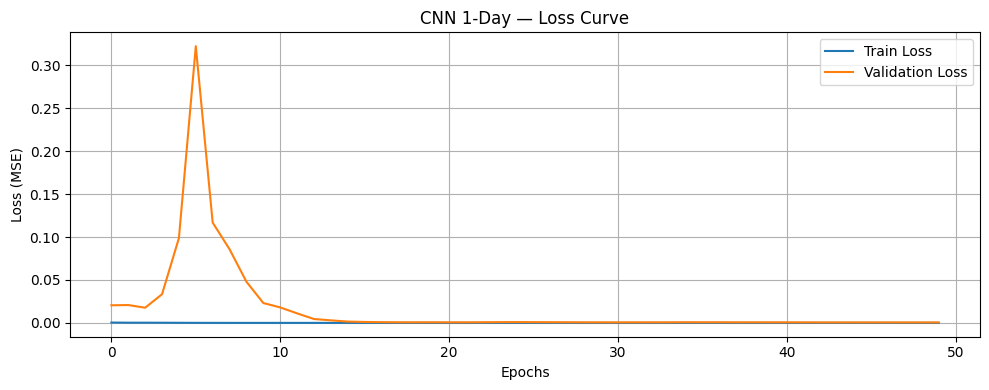

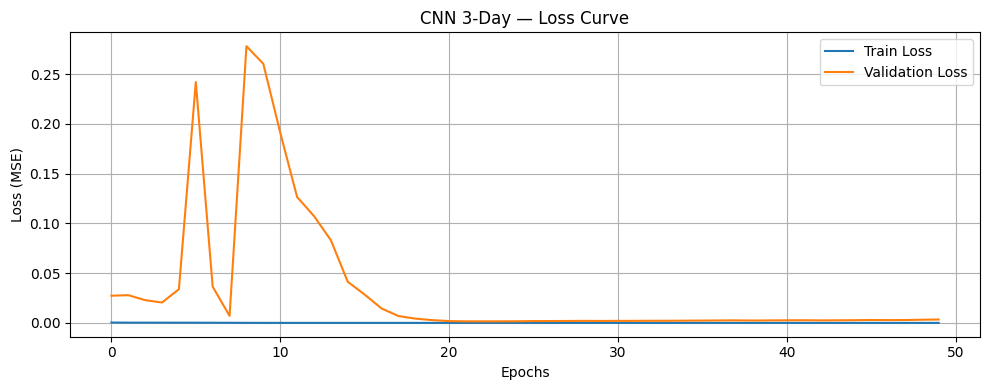

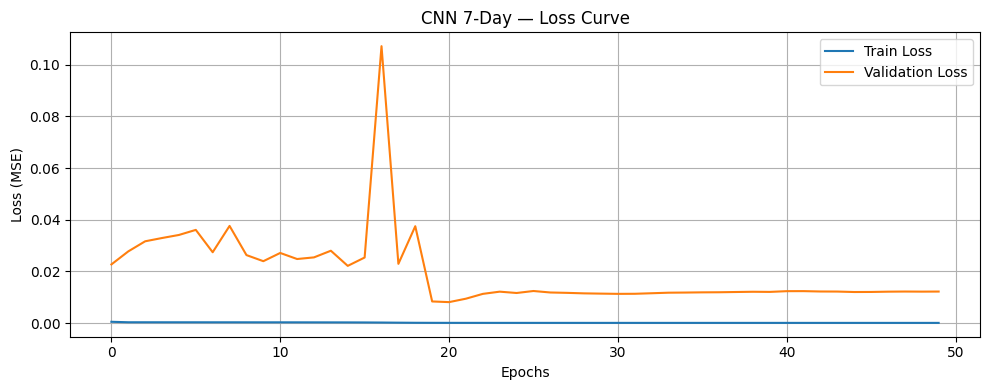

In [64]:
# Ploting loss curves
plot_loss(Cnn_hist_1d, "CNN", "1-Day")
plot_loss(Cnn_hist_3d, "CNN", "3-Day")
plot_loss(Cnn_hist_7d, "CNN", "7-Day")

In [65]:
#  predictions
cnn_pred_1d, cnn_actual_1d, \
cnn_pred_3d, cnn_actual_3d, \
cnn_pred_7d, cnn_actual_7d = get_real_scale_predictions(
    [cnn_model_1d, cnn_model_3d, cnn_model_7d],
    x_test_1d, y_test_1d,
    x_test_3d, y_test_3d,
    x_test_7d, y_test_7d
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [66]:
#   metrics
cnn_mae_1d, cnn_mae_3d, cnn_mae_7d = print_metrics(
    "CNN",
    cnn_pred_1d, cnn_actual_1d,
    cnn_pred_3d, cnn_actual_3d,
    cnn_pred_7d, cnn_actual_7d
)


= CNN — Real Scale Metrics ==
1-Day → MAE: $767.35  | RMSE: $1199.60  | MAPE: 2.14%
3-Day → MAE: $1997.03  | RMSE: $2495.62  | MAPE: 5.43%
7-Day → MAE: $5346.35  | RMSE: $6190.17  | MAPE: 14.57%


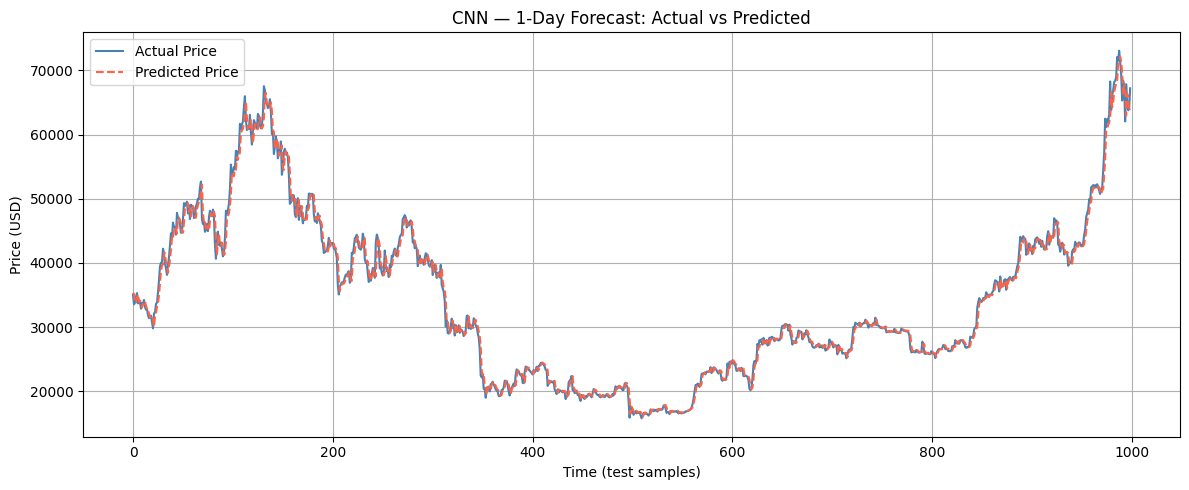

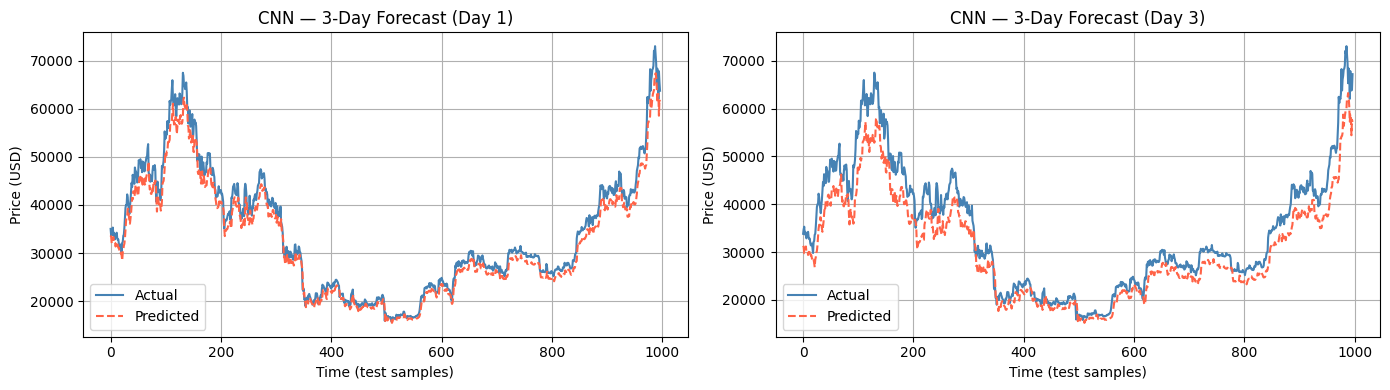

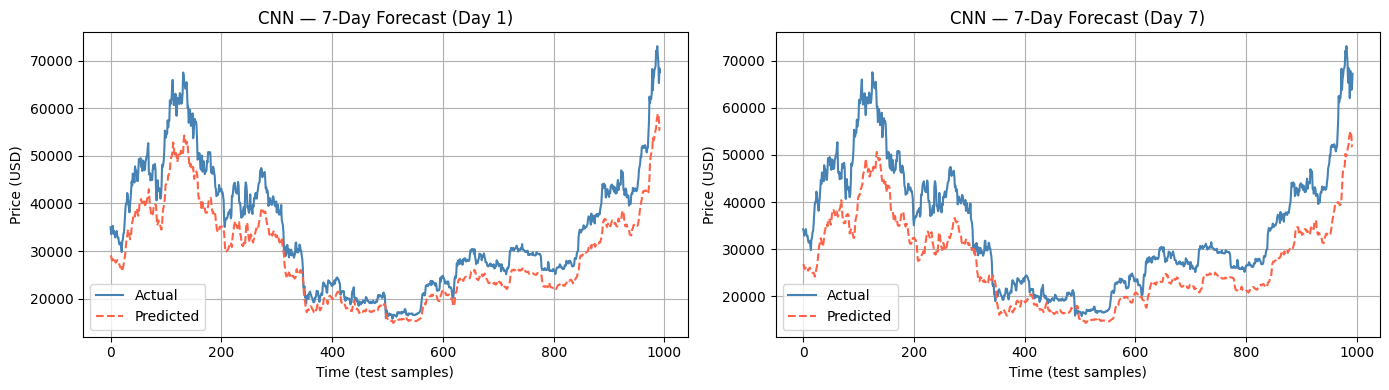

In [67]:
# Ploting predictions
plot_predictions("CNN",
                 cnn_pred_1d, cnn_actual_1d,
                 cnn_pred_3d, cnn_actual_3d,
                 cnn_pred_7d, cnn_actual_7d)

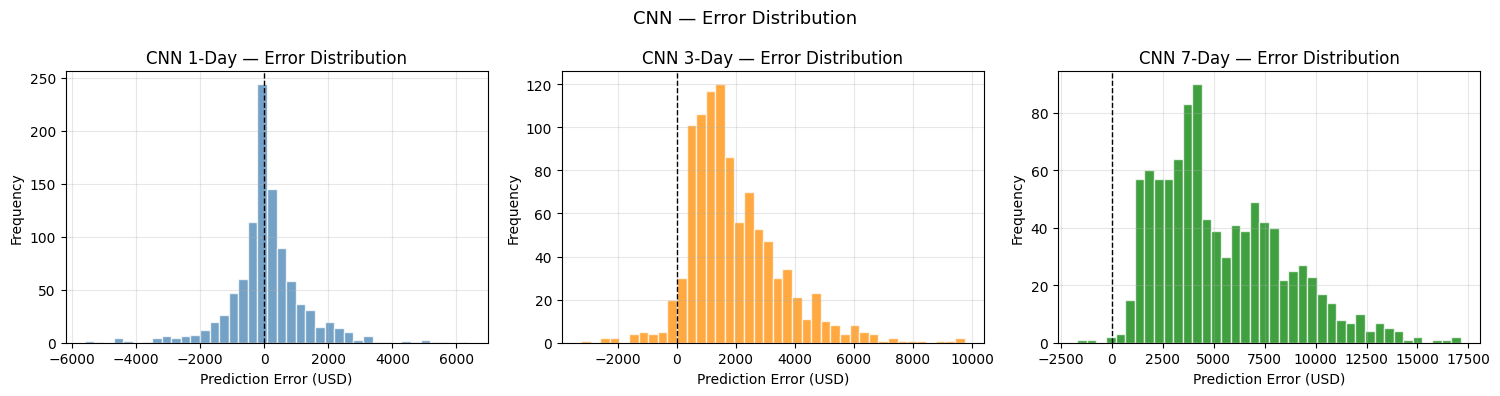

In [68]:
# Ploting error distributions
plot_error_distribution("CNN",
                         cnn_pred_1d, cnn_actual_1d,
                         cnn_pred_3d, cnn_actual_3d,
                         cnn_pred_7d, cnn_actual_7d)

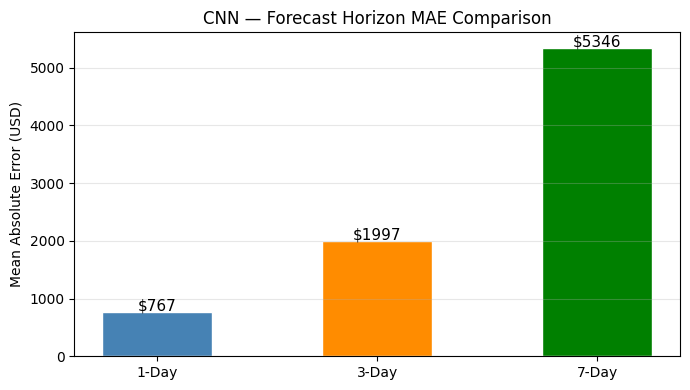

In [69]:
plot_horizon_mae("CNN", cnn_mae_1d, cnn_mae_3d, cnn_mae_7d)

In [70]:
# Future forecast
print_future_forecast("CNN", cnn_model_1d, cnn_model_3d, cnn_model_7d)

## **TRANSFORMER**

In [106]:
def get_positional_encoding(seq_len, d_model):
    positions   = np.arange(seq_len)[:, np.newaxis]
    dims        = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))
    angle_rads  = positions * angle_rates
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return angle_rads[np.newaxis, :, :]   # shape: (1, 60, 64)







In [107]:
def build_transformer(output_days):

    inputs = Input(shape=(60, 1))


    x = Dense(64)(inputs)


    pos_enc = tf.cast(get_positional_encoding(60, 64), dtype=tf.float32)
    x = x + pos_enc
    x = Dropout(0.1)(x)


    attn = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
    attn = Dropout(0.1)(attn)
    x    = LayerNormalization(epsilon=1e-6)(Add()([x, attn]))


    ffn  = Dense(64, activation='relu')(x)
    ffn  = Dense(64)(ffn)
    ffn  = Dropout(0.1)(ffn)
    x    = LayerNormalization(epsilon=1e-6)(Add()([x, ffn]))


    x       = GlobalAveragePooling1D()(x)
    x       = Dense(25, activation='relu')(x)
    outputs = Dense(output_days)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name='mae'),
            tf.keras.metrics.MeanAbsolutePercentageError(name='mape'),
            tf.keras.metrics.RootMeanSquaredError(name='rmse')
        ]
    )
    return model

In [108]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, LayerNormalization, Add
from tensorflow.keras.layers import MultiHeadAttention

In [109]:
# preparing  Transformer models
transformer_model_day_1 = build_transformer(1)
transformer_model_day_3 = build_transformer(3)
transformer_model_day_7 = build_transformer(7)

transformer_model_day_1.summary()
transformer_model_day_3.summary()
transformer_model_day_7.summary()

Model: "functional_45"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 60, 64)    │        128 │ input_layer_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 60, 64)    │          0 │ dense_48[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 60, 64)    │          0 │ add_18[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 64)    │     16,640 │ dropout_24[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 60, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 60, 64)    │          0 │ dropout_24[0][0], │
│                     │                   │            │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_19[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 60, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 60, 64)    │      4,160 │ dense_49[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 60, 64)    │          0 │ dense_50[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 60, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_20[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_51 (Dense)    │ (None, 25)        │      1,625 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 1)         │         26 │ dense_51[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,995 (105.45 KB)

 Trainable params: 26,995 (105.45 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "functional_47"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_58 (Dense)    │ (None, 60, 64)    │        128 │ input_layer_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 60, 64)    │          0 │ dense_58[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_32          │ (None, 60, 64)    │          0 │ add_24[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 64)    │     16,640 │ dropout_32[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_32[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, 60, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_25 (Add)        │ (None, 60, 64)    │          0 │ dropout_32[0][0], │
│                     │                   │            │ dropout_34[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_25[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_59 (Dense)    │ (None, 60, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_60 (Dense)    │ (None, 60, 64)    │      4,160 │ dense_59[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_35          │ (None, 60, 64)    │          0 │ dense_60[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_26 (Add)        │ (None, 60, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_35[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_26[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_61 (Dense)    │ (None, 25)        │      1,625 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_62 (Dense)    │ (None, 7)         │        182 │ dense_61[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,151 (106.06 KB)

 Trainable params: 27,151 (106.06 KB)

 Non-trainable params: 0 (0.00 B)

In [110]:
# Training
print("\nTraining Transformer 1-Day model...")
Transformer_hist_1d = transformer_model_day_1.fit(x_train_1d, y_train_1d,
                                                    epochs=50, batch_size=16,
                                                    validation_split=0.1, verbose=1)


Training Transformer 1-Day model...
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - loss: 0.0093 - mae: 0.0650 - mape: 1021170.3125 - rmse: 0.0964 - val_loss: 0.0153 - val_mae: 0.0895 - val_mape: 18.2529 - val_rmse: 0.1238
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0038 - mae: 0.0492 - mape: 524675.1250 - rmse: 0.0616 - val_loss: 0.0152 - val_mae: 0.0893 - val_mape: 18.6969 - val_rmse: 0.1235
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0022 - mae: 0.0367 - mape: 433723.8438 - rmse: 0.0468 - val_loss: 0.0132 - val_mae: 0.0822 - val_mape: 16.3472 - val_rmse: 0.1147
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0019 - mae: 0.0343 - mape: 435955.5000 - rmse: 0.0437 - val_loss: 0.0129 - val_mae: 0.0821 - val_mape: 16.4849 - val_rmse: 0.1137
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0015 - mae: 0.0303 - mape: 411441.8438 - rmse: 0.0390 - val_loss: 0.0119 - val_mae: 0.0795 - val_mape: 16.0186 - val_rmse: 0.1093


In [111]:

print("\nTraining Transformer 3-Day model...")
Transformer_hist_3d = transformer_model_day_3.fit(x_train_3d, y_train_3d,
                                                    epochs=50, batch_size=16,
                                                    validation_split=0.1, verbose=1)


Training Transformer 3-Day model...
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0065 - mae: 0.0581 - mape: 620623.2500 - rmse: 0.0804 - val_loss: 0.0200 - val_mae: 0.1066 - val_mape: 22.0619 - val_rmse: 0.1416
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0022 - mae: 0.0370 - mape: 420649.0000 - rmse: 0.0470 - val_loss: 0.0192 - val_mae: 0.1006 - val_mape: 18.9886 - val_rmse: 0.1384
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0017 - mae: 0.0320 - mape: 376397.6562 - rmse: 0.0408 - val_loss: 0.0136 - val_mae: 0.0865 - val_mape: 18.5786 - val_rmse: 0.1167
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0012 - mae: 0.0267 - mape: 335201.0625 - rmse: 0.0344 - val_loss: 0.0194 - val_mae: 0.1056 - val_mape: 22.6692 - val_rmse: 0.1392
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.5171e-04 - mae: 0.0235 - mape: 239240.9062 - rmse: 0.0308 - val_loss: 0.0174 - val_mae: 0.0971 - val_mape: 19.4879 - val_rmse: 0.13

In [112]:
print("\nTraining Transformer 7-Day model...")
Transformer_hist_7d = transformer_model_day_7.fit(x_train_7d, y_train_7d,
                                                    epochs=50, batch_size=16,
                                                    validation_split=0.1, verbose=1)


Training Transformer 7-Day model...
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.0133 - mae: 0.0670 - mape: 723881.3125 - rmse: 0.1154 - val_loss: 0.1050 - val_mae: 0.2393 - val_mape: 51.2150 - val_rmse: 0.3240
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0023 - mae: 0.0370 - mape: 366990.3125 - rmse: 0.0478 - val_loss: 0.0244 - val_mae: 0.1052 - val_mape: 20.6354 - val_rmse: 0.1563
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0015 - mae: 0.0299 - mape: 330972.4062 - rmse: 0.0385 - val_loss: 0.0233 - val_mae: 0.1010 - val_mape: 19.9720 - val_rmse: 0.1526
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0012 - mae: 0.0273 - mape: 326871.8750 - rmse: 0.0351 - val_loss: 0.0203 - val_mae: 0.0949 - val_mape: 18.8506 - val_rmse: 0.1424
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0010 - mae: 0.0248 - mape: 265025.3125 - rmse: 0.0318 - val_loss: 0.0219 - val_mae: 0.0937 - val_mape: 17.4838 - val_rmse: 0.1481
E

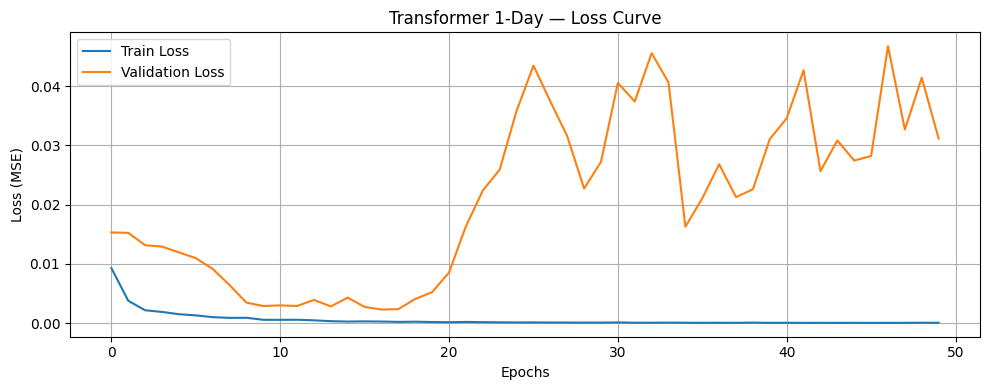

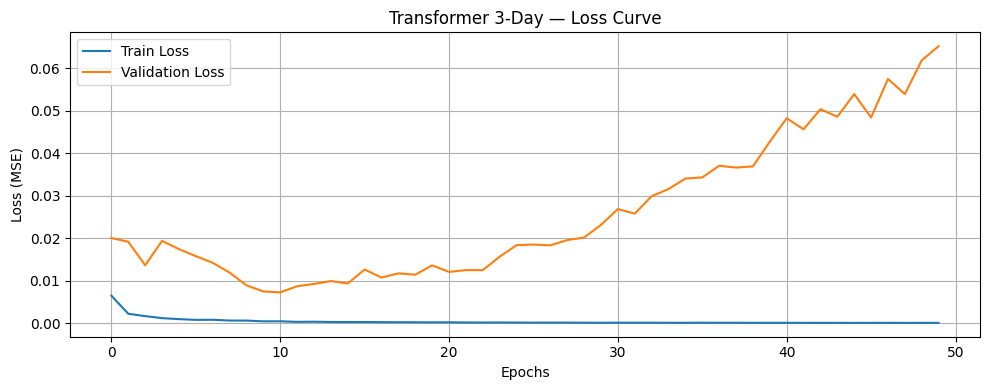

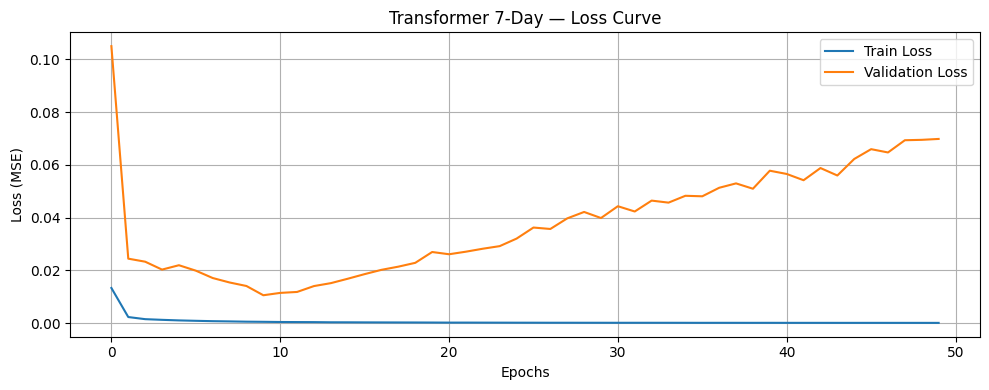

In [113]:

# Ploting loss curves
plot_loss(Transformer_hist_1d, "Transformer", "1-Day")
plot_loss(Transformer_hist_3d, "Transformer", "3-Day")
plot_loss(Transformer_hist_7d, "Transformer", "7-Day")

In [114]:
#  predictions
transformer_pred_1d, transformer_actual_1d, \
transformer_pred_3d, transformer_actual_3d, \
transformer_pred_7d, transformer_actual_7d = get_real_scale_predictions(
    [transformer_model_day_1, transformer_model_day_3, transformer_model_day_7],
    x_test_1d, y_test_1d,
    x_test_3d, y_test_3d,
    x_test_7d, y_test_7d
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [115]:
#  metrics
transformer_mae_1d, transformer_mae_3d, transformer_mae_7d = print_metrics(
    "Transformer",
    transformer_pred_1d, transformer_actual_1d,
    transformer_pred_3d, transformer_actual_3d,
    transformer_pred_7d, transformer_actual_7d
)


== Transformer — Real Scale Metrics ==
1-Day → MAE: $8614.43 | RMSE: $11491.79 | MAPE: 20.88%
3-Day → MAE: $13315.39 | RMSE: $16709.73 | MAPE: 33.82%
7-Day → MAE: $14182.84 | RMSE: $17400.41 | MAPE: 36.62%


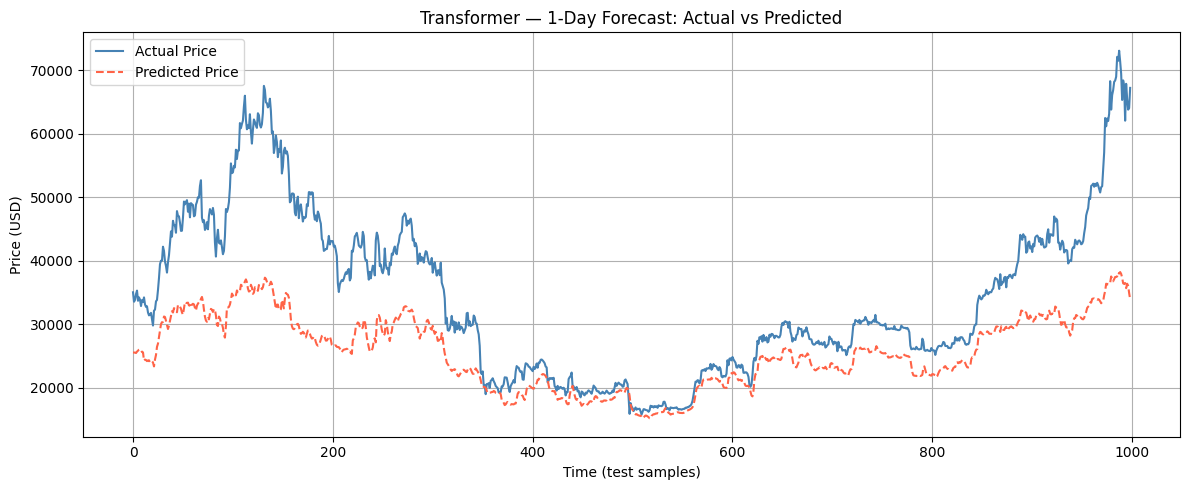

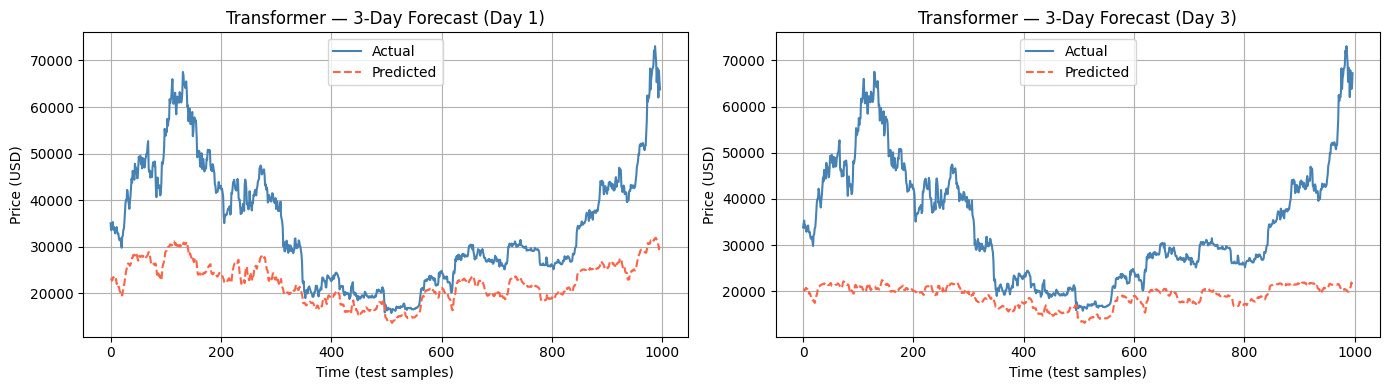

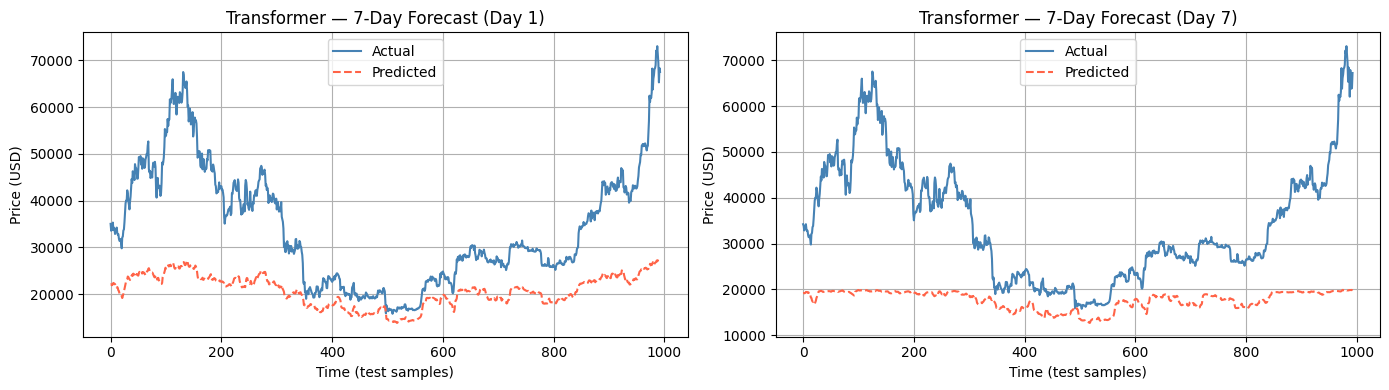

In [116]:
# Ploting predictions
plot_predictions("Transformer",
                 transformer_pred_1d, transformer_actual_1d,
                 transformer_pred_3d, transformer_actual_3d,
                 transformer_pred_7d, transformer_actual_7d)

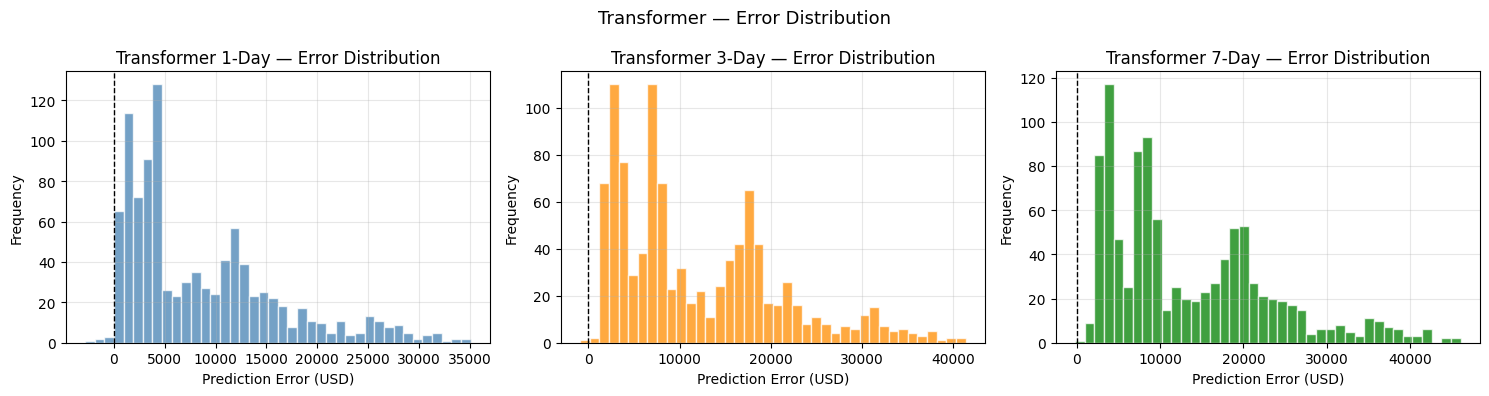

In [117]:
# Ploting error distributions
plot_error_distribution("Transformer",
                         transformer_pred_1d, transformer_actual_1d,
                         transformer_pred_3d, transformer_actual_3d,
                         transformer_pred_7d, transformer_actual_7d)

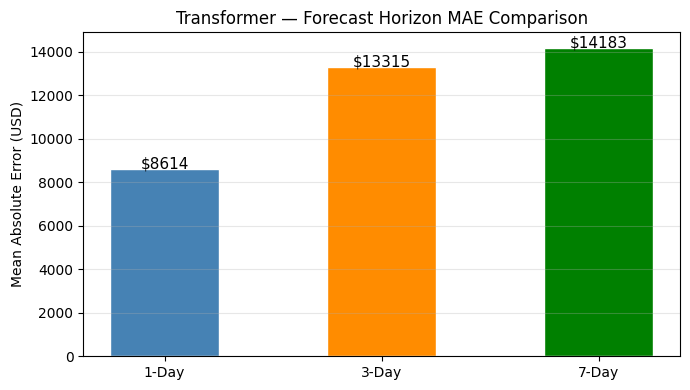

In [118]:
# Horizon MAE bar chart
plot_horizon_mae("Transformer", transformer_mae_1d, transformer_mae_3d, transformer_mae_7d)

In [119]:
# Future forecast
print_future_forecast("Transformer",
                       transformer_model_day_1,
                       transformer_model_day_3,
                       transformer_model_day_7)

# **MODEL COMPARISION**


FINAL COMPARISON — ALL MODELS


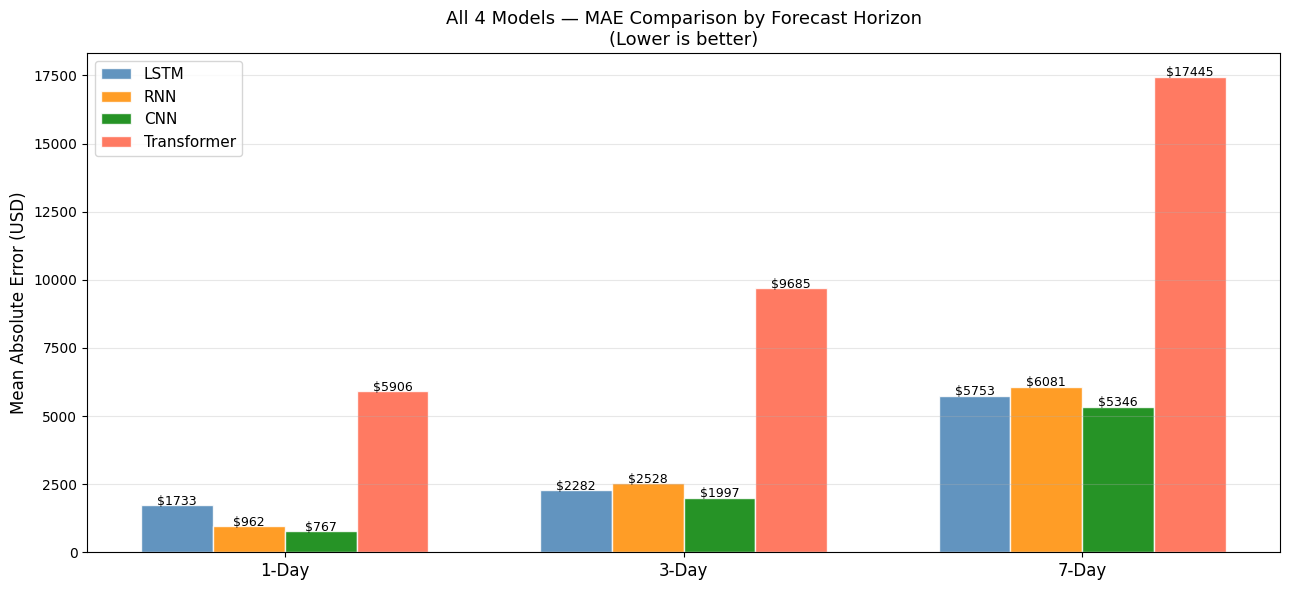


Model            1-Day MAE  3-Day MAE  7-Day MAE
--------------------------------------------------
LSTM               1733.49    2281.79    5752.90
RNN                 962.11    2527.51    6080.89
CNN                 767.35    1997.03    5346.35
Transformer        5906.02    9684.68   17444.71


In [85]:
# MODEL COMPARISON CHART


print("\n" + "="*60)
print("FINAL COMPARISON — ALL MODELS")
print("="*60)

# All MAE values
all_mae = {
    'LSTM':        [lstm_mae_1d,        lstm_mae_3d,        lstm_mae_7d],
    'RNN':         [rnn_mae_1d,         rnn_mae_3d,         rnn_mae_7d],
    'CNN':         [cnn_mae_1d,         cnn_mae_3d,         cnn_mae_7d],
    'Transformer': [transformer_mae_1d, transformer_mae_3d, transformer_mae_7d],
}

horizons    = ['1-Day', '3-Day', '7-Day']
model_names = list(all_mae.keys())
x           = np.arange(len(horizons))
width       = 0.18
colors      = ['steelblue', 'darkorange', 'green', 'tomato']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (name, color) in enumerate(zip(model_names, colors)):
    bars = ax.bar(x + i * width, all_mae[name], width,
                  label=name, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, all_mae[name]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 15,
                f'${val:.0f}', ha='center', fontsize=9)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(horizons, fontsize=12)
ax.set_ylabel("Mean Absolute Error (USD)", fontsize=12)
ax.set_title("All 4 Models — MAE Comparison by Forecast Horizon\n(Lower is better)",
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


print("\n{:<15} {:>10} {:>10} {:>10}".format("Model", "1-Day MAE", "3-Day MAE", "7-Day MAE"))
print("-" * 50)
for name in model_names:
    m = all_mae[name]
    print("{:<15} {:>10.2f} {:>10.2f} {:>10.2f}".format(name, m[0], m[1], m[2]))


FINAL COMPARISON — ALL MODELS



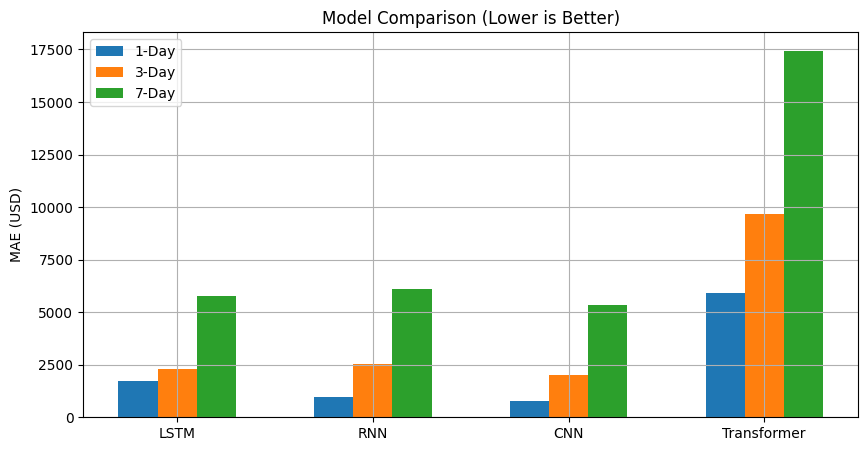


Model       1-Day     3-Day     7-Day
----------------------------------------
LSTM        1733.49    2281.79    5752.90
RNN          962.11    2527.51    6080.89
CNN          767.35    1997.03    5346.35
Transformer  5906.02    9684.68   17444.71


In [86]:
# ---- FINAL COMPARISON ----
print("\nFINAL COMPARISON — ALL MODELS\n")

# Store MAE values in simple lists
models = ["LSTM", "RNN", "CNN", "Transformer"]

mae_1d = [lstm_mae_1d, rnn_mae_1d, cnn_mae_1d, transformer_mae_1d]
mae_3d = [lstm_mae_3d, rnn_mae_3d, cnn_mae_3d, transformer_mae_3d]
mae_7d = [lstm_mae_7d, rnn_mae_7d, cnn_mae_7d, transformer_mae_7d]

# ---- BAR CHART ----
x = np.arange(len(models))

plt.figure(figsize=(10, 5))

plt.bar(x - 0.2, mae_1d, width=0.2, label="1-Day")
plt.bar(x,       mae_3d, width=0.2, label="3-Day")
plt.bar(x + 0.2, mae_7d, width=0.2, label="7-Day")

plt.xticks(x, models)
plt.ylabel("MAE (USD)")
plt.title("Model Comparison (Lower is Better)")
plt.legend()
plt.grid(True)

plt.show()


#  TABLE ----
print("\nModel       1-Day     3-Day     7-Day")
print("----------------------------------------")

for i in range(len(models)):
    print(f"{models[i]:<10} {mae_1d[i]:>8.2f} {mae_3d[i]:>10.2f} {mae_7d[i]:>10.2f}")